In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from IPython.display import clear_output
from dataclasses import replace

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, measure, PipelineConfig, plotting,
    analysis, multicat, selection, core, stack)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins
from utils_lya_halo.stack import build_stacks

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

# Reading in output and stacking

In [2]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.0            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 75             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 80
bg_outer_arcsec = 90

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 1000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg2 = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    n_bootstrap=n_bootstrap,
    #flux_unit='flux_arcsec2',
    #rest_density=False,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg2.cut_radial_bin, cfg2.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
prod_combined = multicat.combine_products(products, label_col="SUBSET")

print(f"AEGIS: {np.round(np.median(product1.nfib, axis=0), 3).astype(int)}")
print(f"COSMOS: {np.round(np.median(product2.nfib, axis=0), 3).astype(int)}")
print(f"COMBINED: {np.round(np.median(prod_combined.nfib, axis=0), 3).astype(int)}")

Finite-spectrum cut (bin 9, > 100 px): kept 233 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 277 / 278 galaxies
combined 2 products -> 510 galaxies (origin in column 'SUBSET')
AEGIS: [    24     70    115    373    911   3128  16911  62091 126573 586721]
COSMOS: [    15     43     70    220    536   1809   9820  37073  87936 402380]
COMBINED: [    17     51     81    258    615   2038  10906  41317  97244 448919]


In [3]:
# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg2, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks_all = stack.build_stacks(cfg2, prod_combined, keep_cube=True)

print(f"BOTH:   {prod_combined.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

# ---------------------------------------------------------------- SEPARATE AGN
sel_agn = prod_combined.catalog["CLEAN"]

groups = selection.split_by_mask(prod_combined, sel_agn, labels=["AGN", "GAL"], verbose=False)
prod_galaxy = groups['GAL']
prod_agn = groups['AGN']

stacks = build_stacks(cfg2, prod_galaxy, keep_cube=True)
stacks_agn = build_stacks(cfg2, prod_agn, keep_cube=True)

print(f"GAL: {prod_galaxy.ngal} sources")
print(f"AGN: {prod_agn.ngal} sources")

BOTH:   510 galaxies
AEGIS:  233 galaxies
COSMOS: 277 galaxies
GAL: 443 sources
AGN: 67 sources


Column Split:

In [50]:
split_col = "INCL_DEG"

split_halves = multicat.split_product_by(
    prod_combined,
    column=split_col,
    percentiles=50,             # scalar -> two bins: 0-50% and 50-100%
    labels=["low", "high"])

low  = split_halves["low"]
high = split_halves["high"]

stacks1 = build_stacks(cfg2, low, keep_cube=True)
stacks2 = build_stacks(cfg2, high, keep_cube=True)

print(low.ngal, high.ngal)

  INCL_DEG low: 254 galaxies
  INCL_DEG high: 254 galaxies
254 254


In [58]:
print(np.nanmedian(low.catalog[split_col]))
print(np.nanmedian(high.catalog[split_col]))

print(np.nanmedian(low.catalog['EBV']))
print(np.nanmedian(high.catalog['EBV']))

print(np.nanmedian(low.catalog['z']))
print(np.nanmedian(high.catalog['z']))

37.75918405819391
60.54762077665761
0.2717934238325397
0.18839275127028426
2.3076
2.3671499999999996


Cone Search:

In [5]:
# hit = selection.cone_search(prod_combined, ra=150.12, dec=2.30, radius_arcsec=30)
# print(hit)                 # <Selection 7/512 galaxies, sep 2.1-28.7">
# hit.catalog               # matched rows, nearest first, with a 'sep_arcsec' column

# st = multicat.build_stacks(cfg2, hit.product)   # hit.product is stack-ready

# selection.plot_sky(prod_combined, hit, center=(150.12, 2.30), radius_arcsec=30)

Different Halo Catalog

In [6]:
# file_name1 = './outputs/galaxy_cat11f6d7_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits'
# file_name2 = './outputs/galaxy_cat11f6d7_b7_661367_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits'

# products = multicat.load_products(
#     [
#         {"label": "cat1", "path": file_name1},
#         {"label": "cat2", "path": file_name2},
#     ],
#     base_config=cfg,      # supplies cut_radial_bin / min_good_wave for the finite cut
#     apply_cut=True,
# )

# stacks = multicat.stack_each(cfg, products, keep_cube=True)
# stacks_cat1 = stacks["cat1"]
# stacks_cat2 = stacks["cat2"]

Selection Cuts:

/tmp/ipykernel_32334/1674912638.py:4: RuntimeWarning: invalid value encountered in log10
  edges=[10**((np.log10(sigma_sfr[np.isfinite(sigma_sfr)])).mean())],  # or your boundary


<Axes: title={'center': 'Split quantity distribution'}, xlabel='sigma_SFR', ylabel='galaxies'>

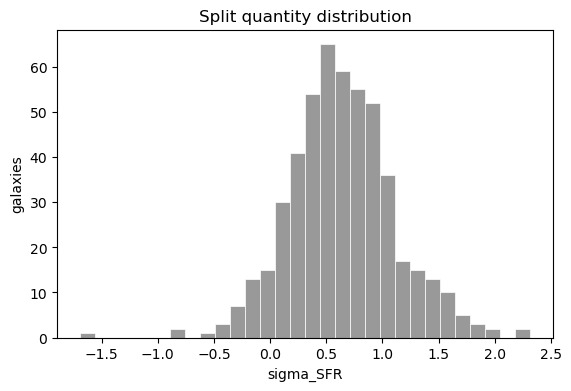

In [42]:
# see the distribution + where it split:
sigma_sfr = selection.derive(prod_combined, "SFR_50 / (np.pi*(RE_BEST**2))")
selection.plot_split_hist(prod_combined, "SFR_50 / (np.pi*(RE_BEST**2))",
                    edges=[10**((np.log10(sigma_sfr[np.isfinite(sigma_sfr)])).mean())],  # or your boundary
                    log=True, xlabel="sigma_SFR")

In [43]:
#s = selection.select_by(prod_combined, "(z < 3.5)") #Include selection cuts like (SUBSET == 'cat1') & (z < 2.5)

halves = selection.split_by_derived(prod_combined, "SFR_50 / (np.pi*(RE_BEST**2))",
                                         name="sigma_SFR", percentiles=50,
                                         labels=["low", "high"])

split_by_derived on 'sigma_SFR':
  sigma_SFR low: 254 galaxies
  sigma_SFR high: 254 galaxies


Mask Input

In [8]:
# categorical works too: an array of strings/ints -> one group per unique value
#my_mask = (mega.catalog["z"] < 2.75) & np.ones_like(mega.catalog["z"]).astype('bool')
#my_mask = (mega.catalog["MASS_50"] > 9.9) & (mega.catalog["MASS_50"] < 11.1)
# my_mask = (mega.catalog["MASS_50"] > 10.5)

# groups = selection.split_by_mask(mega, my_mask, labels=["cold", "hot"])

# g1 = groups['cold']
# g2 = groups['hot']

# stacks1 = build_stacks(cfg_prod, g1, keep_cube=True)
# stacks2 = build_stacks(cfg_prod, g2, keep_cube=True)

Controlled Column Split

In [4]:
# split_col = "MASS_50"
# control_col = "SFR_50"
# - Different large-radius centroid values

# split_col = "RE_BEST"
# control_col = "MASS_50"

# split_col = "EBV"
# control_col = "MASS_50"

# split_col = "AGE_50"
# control_col = "MASS_50"

split_col = "z"
control_col = "MASS_50"
# - Different flux break points

In [5]:
low_mask, high_mask = selection.split_controlled(prod_combined.catalog,
                                       split_col=split_col,
                                       control_col=control_col,
                                       n_control_bins=5)

labels = np.full(len(prod_combined.catalog), "skip", dtype="U4")
labels[low_mask], labels[high_mask] = "low", "high"
groups = selection.split_by_mask(prod_combined, labels)
g_low, g_high = groups["low"], groups["high"]

stacks1 = build_stacks(cfg2, g_low,  keep_cube=True) #LOW
stacks2 = build_stacks(cfg2, g_high, keep_cube=True)  #HIGH

  MASS_50 [8.23,9.4): 102 gal  low=51  high=51
  MASS_50 [9.4,9.72): 102 gal  low=51  high=51
  MASS_50 [9.72,9.99): 102 gal  low=51  high=51
  MASS_50 [9.99,10.4): 101 gal  low=50  high=51
  MASS_50 [10.4,11.7): 103 gal  low=52  high=51

z split at fixed MASS_50 (median):
  low :  255 gal,  median MASS_50=9.84,  median z=2.19
  high:  255 gal,  median MASS_50=9.86,  median z=2.97
  MASS_50 offset between halves: 0.02  (want ~0)
  high: 255 galaxies
  low: 255 galaxies


Separate Catalog Column - Lya Class Separation

In [9]:
# prod_egs = core.read_core_fits("6-23-26-core_extraction_egs_MF.fits")
# prod_cosmos = core.read_core_fits("6-23-26-core_extraction_cosmos_MF.fits")
# prod_core = stack.concat_core_prods(prod_egs, prod_cosmos)

# # --- build CLASS on prod_core's full axis (notebook-specific bookkeeping) ---
# cat_core = prod_core['catalog']
# labels = np.asarray(prod_core['results']['label'], dtype=object).copy()
# labels[np.asarray(cat_core['AGN_FLAG'], dtype=bool)] = 'AGN'   # AGN overrides
# labels[~np.asarray(cat_core['KEEP'],     dtype=bool)] = ''     # non-KEEP -> unclassified
# ext = cat_core.copy()
# ext['CLASS'] = labels

# # --- carry CLASS onto mega by position, then split: two calls ---
# mega2 = multicat.add_matched_column(mega, ext, 'CLASS', radius_arcsec=0.1)

# idx, sep, matched = multicat.match_catalog(mega, ext, radius_arcsec=0.1)
# print(f"{matched.sum()}/{mega.ngal} matched; median sep {np.nanmedian(sep):.3f}\"")

# groups = multicat.split_product_by(
#     mega2, 'CLASS',
#     groups=[['AGN'], ['LAE'], ['emitter'], ['null'], ['absorber'],
#             ['LAE', 'emitter'], ['null', 'absorber']],
#     labels=['AGN', 'LAE', 'emitter', 'null', 'absorber', 'bright', 'dim'])

# print({k: v.ngal for k, v in groups.items()})

In [10]:
# agn = groups['AGN']
# lae = groups['LAE']
# emitter = groups['emitter']
# null = groups['null']
# absorber = groups['absorber']
# bright = groups['bright']
# dim = groups['dim']

# stacks1 = build_stacks(cfg_prod, agn, keep_cube=True)
# stacks2 = build_stacks(cfg_prod, lae, keep_cube=True)
# stacks3 = build_stacks(cfg_prod, emitter, keep_cube=True)
# stacks4 = build_stacks(cfg_prod, null, keep_cube=True)
# stacks5 = build_stacks(cfg_prod, absorber, keep_cube=True)
# stacks6 = build_stacks(cfg_prod, bright, keep_cube=True)
# stacks7 = build_stacks(cfg_prod, dim, keep_cube=True)

# clear_output()

# Simple Plotting and Measurements

/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/plotting.py:339: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i, 0].legend(fontsize=11, frameon=False, loc="upper right")


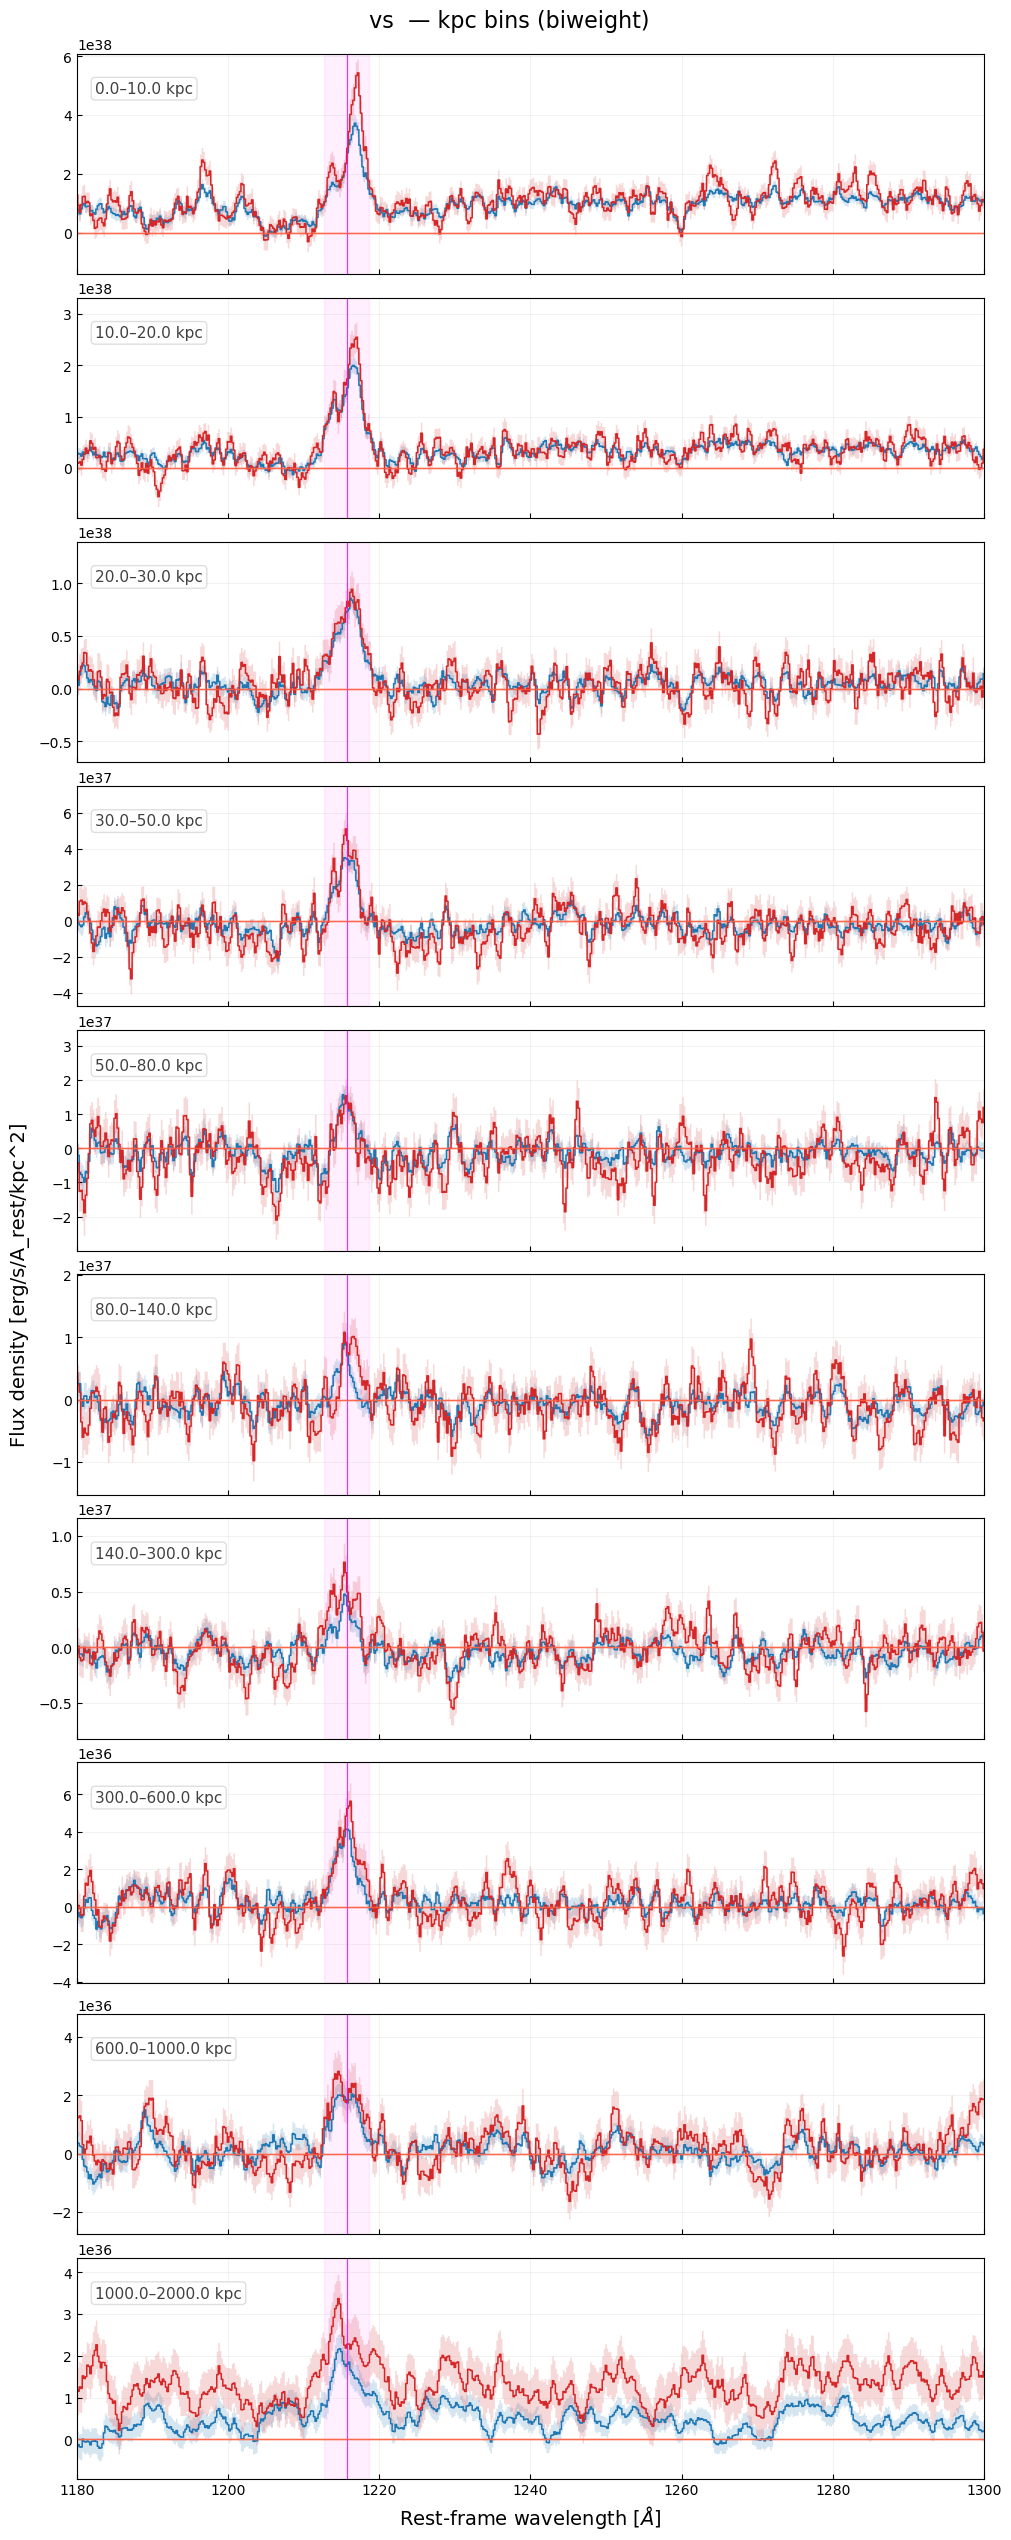

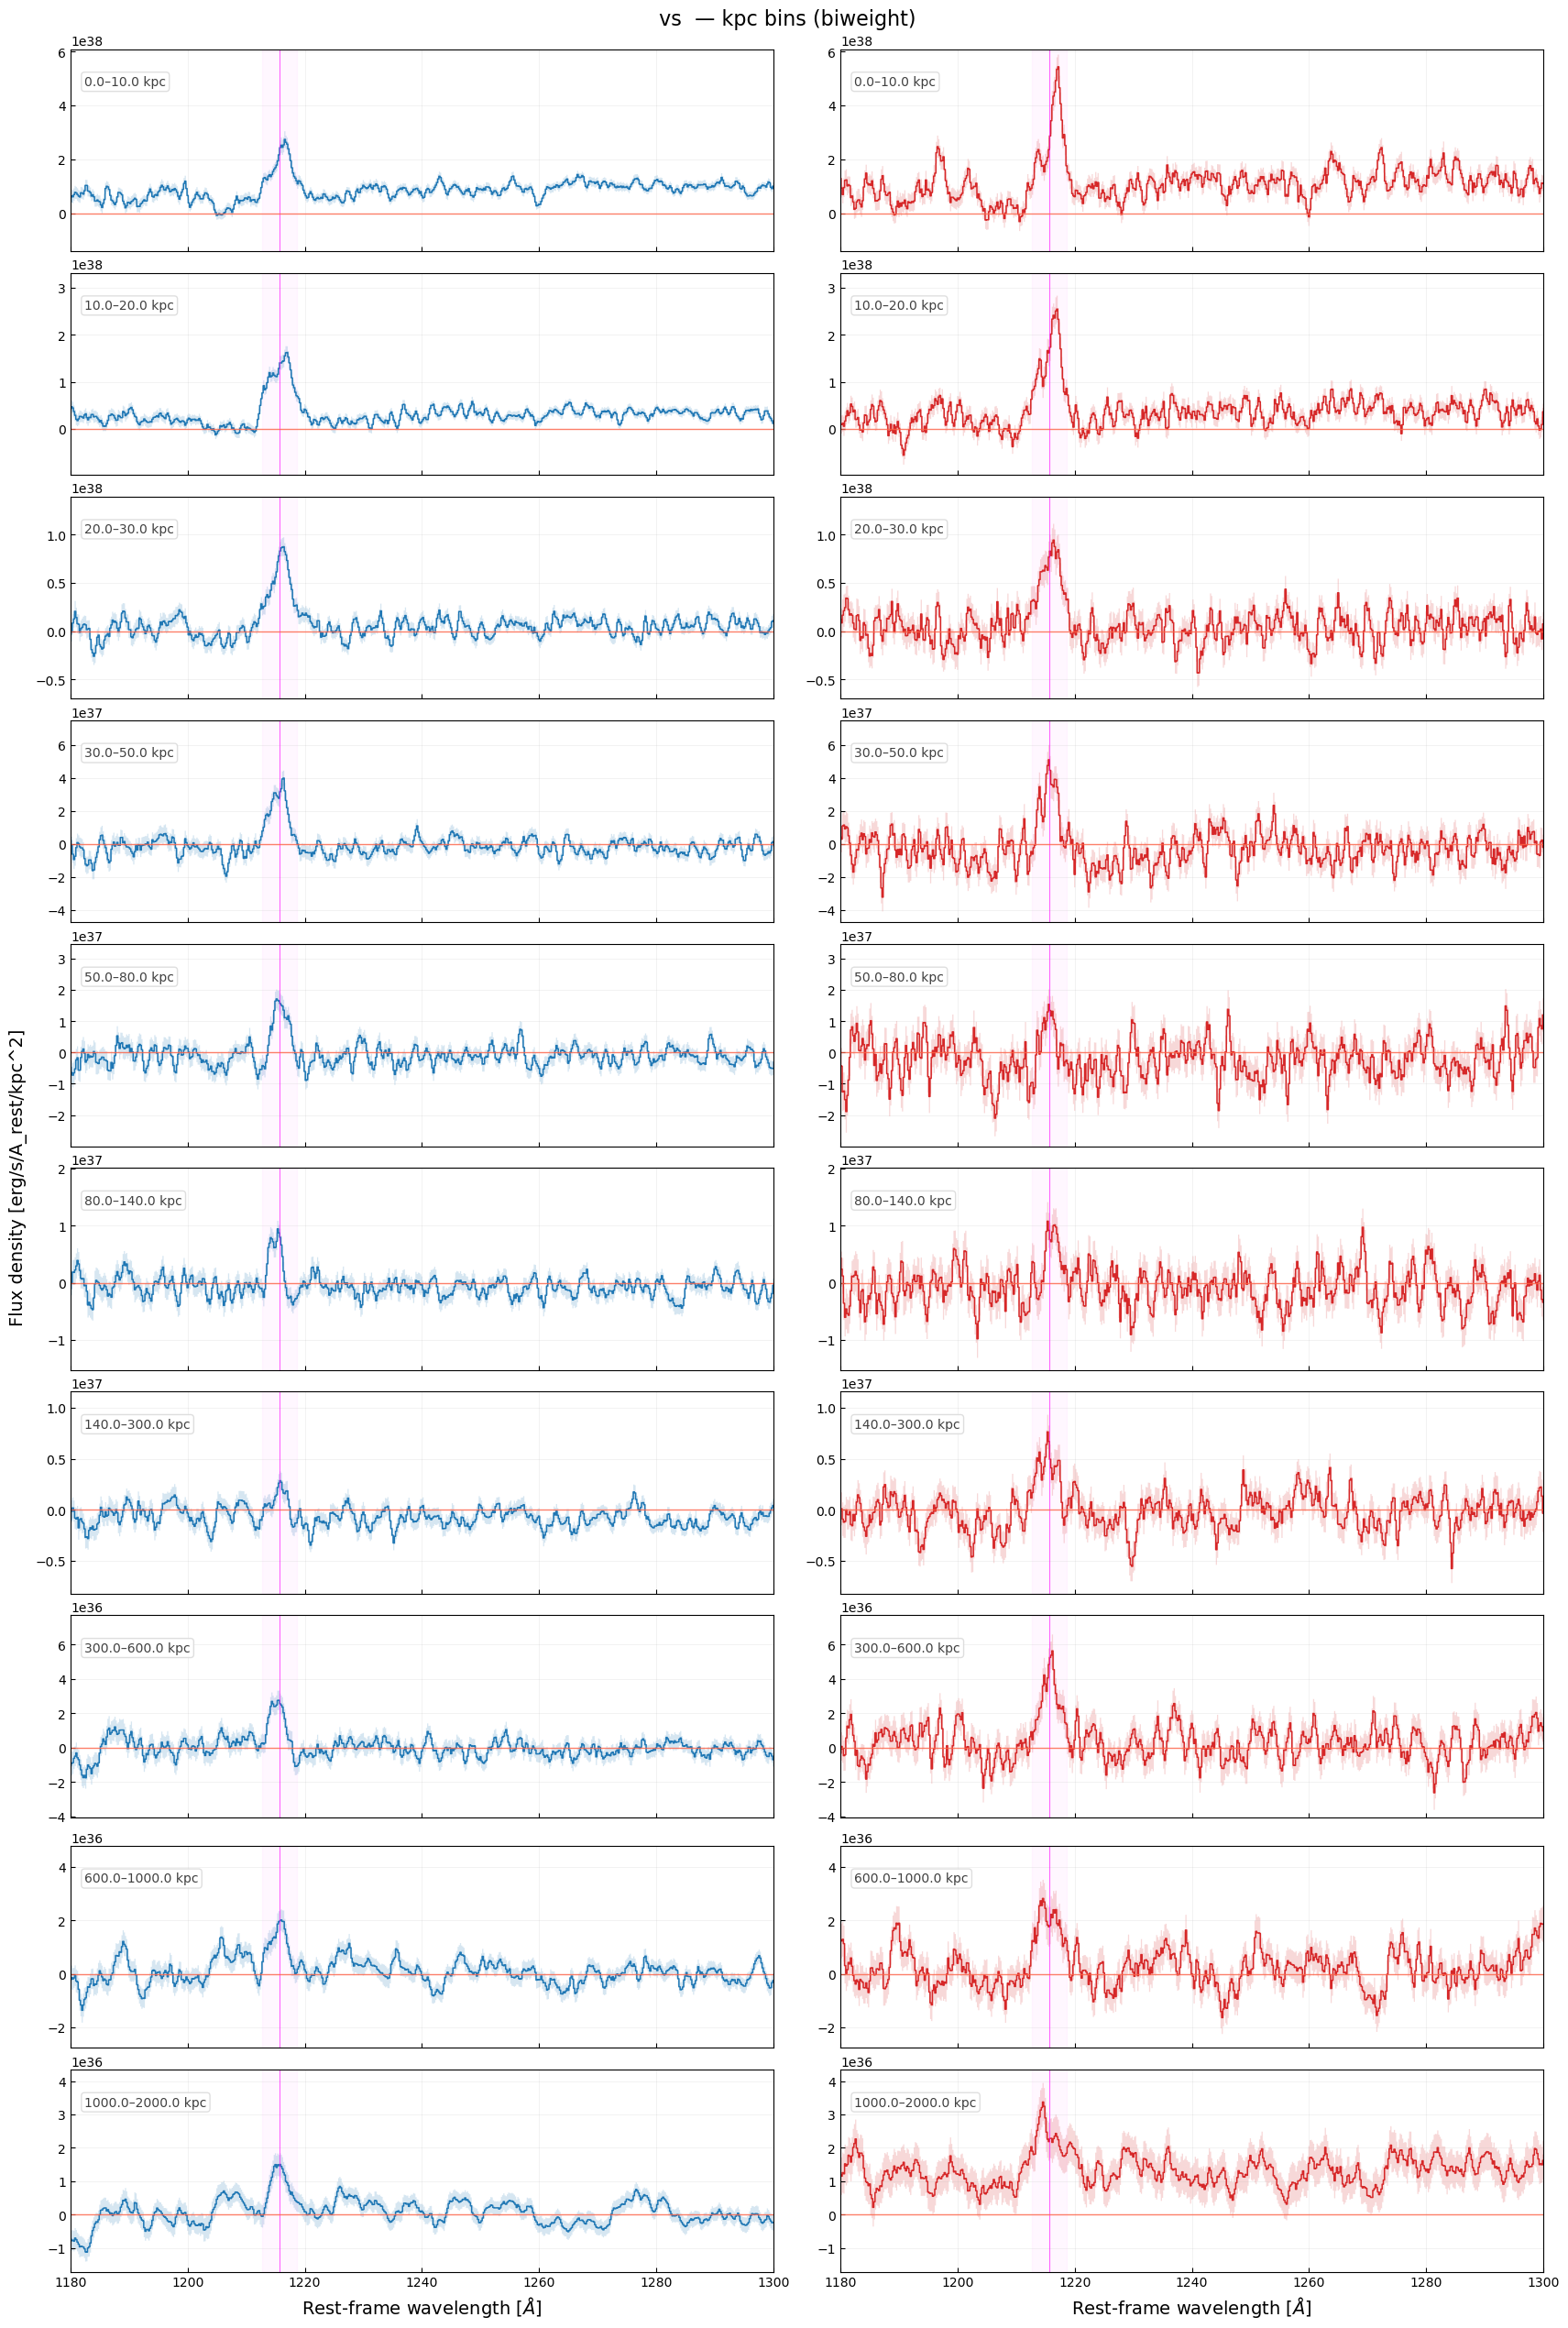

(<Figure size 1700x2500 with 20 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: xlabel='Rest-frame wavelength [$\\AA$]'>,
         <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>]], dtype=object))

In [6]:
# all radial bins, both half-stacks on one figure
plotting.plot_stack_panels_two(stacks, stacks2,
                               method=stack_method,
                               distance_type=bin_mode,
                               labels=["", ""],
                               layout="overlay",
                               xlim=(1180, 1300),
                               lya_window=half_width)
plotting.plot_stack_panels_two(stacks1, stacks2,
                               method=stack_method,
                               distance_type=bin_mode,
                               labels=["", ""],
                               layout="side",
                               xlim=(1180, 1300),
                               lya_window=half_width)

# Bootstrap

In [7]:
boot1 = measure.measure_all_bins(cfg2, stacks1,
    seed=random_seed,
    verbose=True)
boot2 = measure.measure_all_bins(cfg2, stacks2,
    seed=random_seed,
    verbose=True)

▶ bootstrap [median50]  |  nboot=1000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=10


bootstrap [median50]:   0%|          | 0/1000 [00:00<?, ?it/s]

▶ bootstrap [median50]  |  nboot=1000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=10


bootstrap [median50]:   0%|          | 0/1000 [00:00<?, ?it/s]

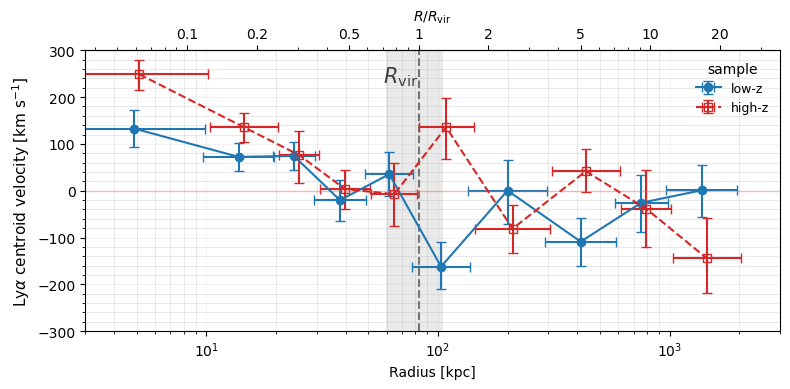

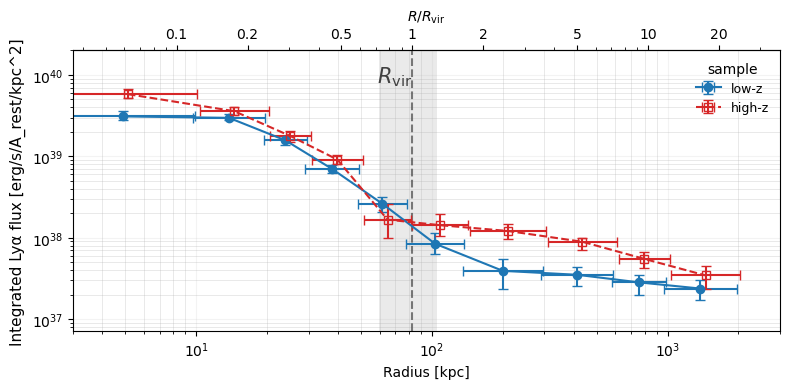

(<Figure size 800x400 with 1 Axes>,
 <Axes: xlabel='Radius [kpc]', ylabel='Integrated Lyα flux [erg/s/A_rest/kpc^2]'>)

In [11]:
# shared setup
labels = ("low-z", "high-z")
xlims = (3, 3000)
vr_ticks = (0.1, 0.2, 0.5, 1, 2, 5, 10, 20)

# --- centroid ---
analysis.plot_centroid_profile_two(
    boot1, boot2, stacks1, stacks2,
    labels=labels,
    bin_mode="kpc", xlims=xlims, vr_ticks=vr_ticks,
    ylims=(-300, 300),
    colors=("tab:blue", "tab:red"),      # sample A / sample B
    fmts=("o-", "s--"),                  # A solid, B open/dashed
    markersize=6, linewidth=1.5, capsize=3.5,
    sample_b_alpha=1.0,                  # how faded sample B looks
    jitter=0.05,                         # x-offset so error bars don't overlap
    figsize=(8, 4),
    title=None,                          # None = no header (default)
    legend_title="sample",
    save_fig=False, save_name="Centroid_Comparison_z",
)

# --- flux ---
analysis.plot_flux_profile_two(
    boot1, boot2, stacks1, stacks2,
    labels=labels,
    bin_mode="kpc", xlims=xlims, vr_ticks=vr_ticks,
    logy=True,                           # False -> linear, union y-limits over both samples
    sample_b_alpha=1.0,                  # how faded sample B looks
    colors=("tab:blue", "tab:red"),
    jitter=0.05,
    figsize=(8, 4),
    title=None,
    save_fig=False, save_name="Surface_Luminosity_Comparison_z",
)